# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-09 14:38:20,196] A new study created in memory with name: no-name-2bbe750a-7153-4496-8def-92140b301ab2
[I 2026-04-09 14:38:20,383] Trial 0 finished with value: 0.6782608695652174 and parameters: {'n_estimators': 194, 'max_depth': 3}. Best is trial 0 with value: 0.6782608695652174.
[I 2026-04-09 14:38:20,555] Trial 1 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 152, 'max_depth': 15}. Best is trial 1 with value: 0.7424242424242424.
[I 2026-04-09 14:38:20,819] Trial 2 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 236, 'max_depth': 13}. Best is trial 1 with value: 0.7424242424242424.
[I 2026-04-09 14:38:21,105] Trial 3 finished with value: 0.7480916030534351 and parameters: {'n_estimators': 256, 'max_depth': 12}. Best is trial 3 with value: 0.7480916030534351.
[I 2026-04-09 14:38:21,351] Trial 4 finished with value: 0.734375 and parameters: {'n_estimators': 217, 'max_depth': 10}. Best is trial 3 with value: 0.748091603053435

RF F1: 0.7575757575757576
LR F1: 0.71875
SVM F1: 0.71875
KNN F1: 0.7555555555555555


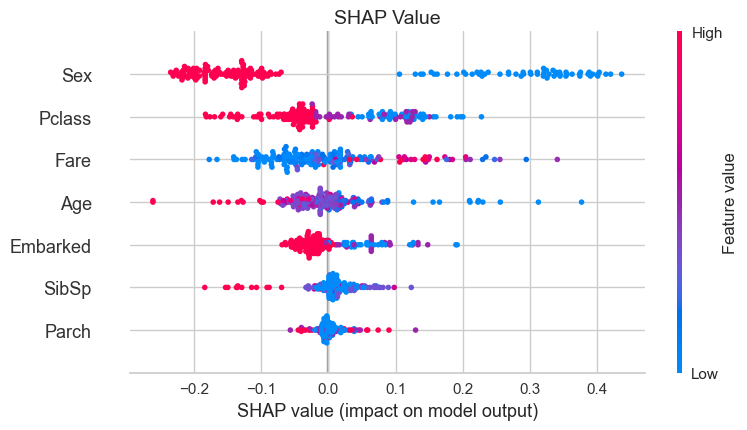

Stacking F1: 0.7480916030534351


In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [1]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.8641,0.8583,0.4839,0.7701,0.5934,0.5170,0.5376,1.1410
lightgbm,Light Gradient Boosting Machine,0.8579,0.8495,0.4935,0.7287,0.5869,0.5051,0.5199,0.1190
gbc,Gradient Boosting Classifier,0.8643,0.8565,0.4614,0.7912,0.5812,0.5073,0.5343,0.1480
xgboost,Extreme Gradient Boosting,0.8507,0.8346,0.4996,0.6895,0.5787,0.4909,0.5007,0.0390
ada,Ada Boost Classifier,0.8568,0.8389,0.4735,0.7352,0.5747,0.4937,0.5117,0.0610
rf,Random Forest Classifier,0.8580,0.8393,0.4588,0.7541,0.5691,0.4904,0.5128,0.1500
et,Extra Trees Classifier,0.8507,0.8344,0.4344,0.7291,0.5441,0.4618,0.4840,0.0980
dt,Decision Tree Classifier,0.7868,0.6865,0.5161,0.4829,0.4986,0.3635,0.3640,0.0130
qda,Quadratic Discriminant Analysis,0.8366,0.8107,0.3189,0.7379,0.4445,0.3661,0.4109,0.0100
lr,Logistic Regression,0.8116,0.7381,0.1868,0.6494,0.2892,0.2171,0.2742,1.0460


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

In [3]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

In [4]:
new_df = df.drop(columns = ['customer_id'], errors = 'ignore')

# customer_id 같은 경우 분석에 있어서 중요한 칼럼이 아니기에 제거했습니다.

In [5]:
le = LabelEncoder()
new_df['gender'] = le.fit_transform(new_df['gender'])
new_df['country'] = le.fit_transform(new_df['country'])
# gender의 경우 남성 여성이기에 0과 1로 라벨인코딩을 진행했습니다.
# country의 경우 또한 France, Germany, Spain 3개이기에 0, 1, 2로 라벨인코딩을 진행했습니다.
# 결측치는 모든 칼럼에서 없기에 따로 처리하지 않았습니다

<Axes: xlabel='products_number'>

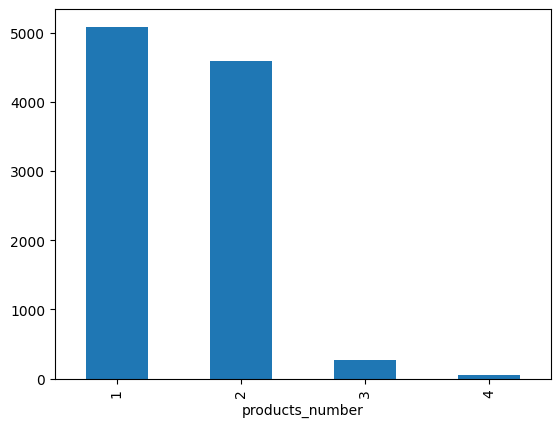

In [6]:
new_df['products_number'].value_counts().plot(kind = 'bar')

# 고객의 대다수가 1~2개의 상품에 집중되어 있습니다.
# 따라서 상품 1~2개 보유 고객을 3개 이상의 충성 고객으로 전환시키는 전략이 필요하다고 생각됩니다.

<Axes: xlabel='age'>

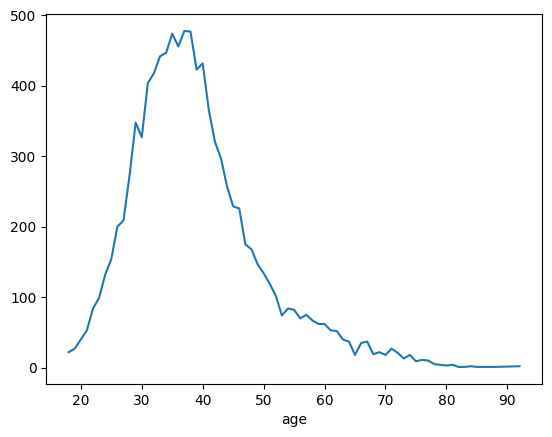

In [ ]:
new_df['age'].value_counts().sort_index().plot(kind = 'line')

# 주 고객층은 30 ~ 40대이며 연령대가 올라갈수록 적어진다는 것을 알 수 있습니다.
# 20대에서 급격하게 상승하는 그래프로 20대 고객들을 주 고객층으로 어떻게 만들지를 생각해보는것이 향후에 좋을 것 같습니다.

In [ ]:
X = new_df.drop(columns = ['churn'])
y = new_df['churn']

# X같은 경우 정답값인 churn을 제외한 모든 칼럼으로 지정하였습니다.
# y같은 경우 정답값으로 churn을 지정하였습니다.

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

# 8:2로 분리하였습니다.

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_valid = ss.transform(X_valid)

# 데이터에 balance와 같이 다른 칼럼에 비해 너무 튀는 수치가 있어 표준화로 리스케일링을 진행하였습니다.

In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier

def objective_cat(trial): # objective_cat이라는 것을 정의합니다.
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500), # 100 ~ 500 사이의 횟수로 학습을 진행합니다.
        'depth': trial.suggest_int('depth', 4, 10), # 깊이를 4 ~ 10 사이로 설정합니다.
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log = True), # 0.1 ~ 0.3 사이의 작은 오차를 세밀하게 탐색합니다.
        'random_strength' : trial.suggest_int('random_strength', 1, 10), # 랜덤성을 부여하여 과적합을 방지하였습니다.
        'verbose' : False, # 학습과정을 출력하지 않고 깔끔하게 나오게 합니다.
        'random_state' : 42
    }
    model = CatBoostClassifier(**params) # 모델을 catboostclassifier라고 지정하며 params를 땡겨옵니다.
    model.fit(X_train, y_train) # 모델을 학습시킵니다.
    pred = model.predict(X_valid) # 예측값을 뽑아냅니다.
    return f1_score(y_valid, pred) # 정답값과 예측값을 이용하여 f1 score를 뽑아냅니다.

def objective_lgbm(trial): # objective_lgbm이라는 것을 정의합니다.
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 100, 500), # 학습할 나무의 갯수를 100 ~ 500개로 지정하였습니다.
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log = True), # 0.1 ~ 0.3 사이의 작은 오차를 세밀하게 탐색합니다.
        'max_depth' : trial.suggest_int('max_depth', 3, 15), # 최대 깊이를 3 ~ 15로 설정하여 너무 복잡해지지 않게 합니다.
        'num_leaves' : trial.suggest_int('num_leaves', 20, 100), # 말단 노드를 20 ~ 100개로 설정하여 너무 복잡해지지 않도록 합니다.
        'verbose' : -1 
    }
    model = LGBMClassifier(**params, random_state=42) # 모델을 LGBMClassifier라고 지정하며 params를 땡겨옵니다.
    model.fit(X_train, y_train) # 모델을 학습시킵니다.
    pred = model.predict(X_valid) # 예측값을 뽑아냅니다.
    return f1_score(y_valid, pred) # 정답값과 예측값을 이용하여 f1 score를 뽑아냅니다.


def objective_gbc(trial): # objective_gbc라는 것을 정의합니다.
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 100, 300), # 학습할 나무의 갯수를 100 ~ 300개로 지정하였습니다.
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.2, log = True), # 0.1 ~ 0.2 사이의 작은 오차를 세밀하게 탐색합니다.
        'max_depth' : trial.suggest_int('max_depth', 3, 8), # 최대 깊이를 3 ~ 8로 설정하여 너무 복잡해지지 않게 합니다.
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20), # 노드를 분할하기 위해 필요한 샘플 수를 2 ~ 20으로 설정합니다.
        'subsample' : trial.suggest_float('subsample', 0.3, 1.0) # 각 학습시 사용할 데이터 비율을 0.3 : 1.0 으로 합니다.
    }
    model = GradientBoostingClassifier(**params, random_state=42) # 모델을 GradientBoostingClassifier라고 지정하며 params를 땡겨옵니다.
    model.fit(X_train, y_train) # 모델을 학습시킵니다.
    pred = model.predict(X_valid) # 예측값을 뽑아냅니다.
    return f1_score(y_valid, pred) # 정답값과 예측값을 이용하여 f1 score를 뽑아냅니다.


# 위에서 가장 강력한 모델로 상위 3개를 봤을때 cat, lgbm, gbc 모델이라는 것을 알 수 있었습니다.
# optuna를 활용하여 최적의 파라미터를 찾기 위해 코드를 짰습니다.

In [ ]:
study_cat = optuna.create_study(direction='maximize'); study_cat.optimize(objective_cat, n_trials=10)  
# CatBoost 모델의 성능을 가장 높게 만드는 파라미터 조합을 찾기 위해, 위에서 만든 규칙에 따라 총 10번의 실험을 진행합니다.
study_lgbm = optuna.create_study(direction='maximize'); study_lgbm.optimize(objective_lgbm, n_trials=10)
# LGBM 모델의 성능을 가장 높게 만드는 파라미터 조합을 찾기 위해, 위에서 만든 규칙에 따라 총 10번의 실험을 진행합니다.
study_gbc = optuna.create_study(direction='maximize'); study_gbc.optimize(objective_gbc, n_trials=10)
# GBC 모델의 성능을 가장 높게 만드는 파라미터 조합을 찾기 위해, 위에서 만든 규칙에 따라 총 10번의 실험을 진행합니다.

# 각 모델마다 옵튜나를 적용하여 최적의 파라미터를 찾습니다.

[I 2026-04-09 15:19:59,612] A new study created in memory with name: no-name-6966e936-011e-4846-adc8-da763551fd02
[I 2026-04-09 15:20:01,329] Trial 0 finished with value: 0.5944272445820433 and parameters: {'iterations': 276, 'depth': 9, 'learning_rate': 0.03121313977378599, 'random_strength': 6}. Best is trial 0 with value: 0.5944272445820433.
[I 2026-04-09 15:20:02,115] Trial 1 finished with value: 0.5113043478260869 and parameters: {'iterations': 303, 'depth': 5, 'learning_rate': 0.012999531253929913, 'random_strength': 10}. Best is trial 0 with value: 0.5944272445820433.
[I 2026-04-09 15:20:03,072] Trial 2 finished with value: 0.596875 and parameters: {'iterations': 455, 'depth': 4, 'learning_rate': 0.028954877849723545, 'random_strength': 9}. Best is trial 2 with value: 0.596875.
[I 2026-04-09 15:20:03,446] Trial 3 finished with value: 0.5942684766214178 and parameters: {'iterations': 182, 'depth': 6, 'learning_rate': 0.18625125074935497, 'random_strength': 10}. Best is trial 2 wi

In [ ]:
cat = CatBoostClassifier(**study_cat.best_params, verbose= False)
# 위에서의 실험읕 통해 최고의 파라미터를 가져옵니다.
lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42)
# 위에서의 실험읕 통해 최고의 파라미터를 가져옵니다.
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
# 위에서의 실험읕 통해 최고의 파라미터를 가져옵니다.

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의합니다.

In [ ]:
cat.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
gbc.fit(X_train, y_train)

# 모델에 맞춰 학습시킵니다.

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.031088712168401207, loss='log_loss',
                           max_depth=6, max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=10, min_weight_fraction_leaf=0.0,
                           n_estimators=208, n_iter_no_change=None,
                           random_state=42, subsample=0.49706759895259384,
                           tol=0.0001, validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [ ]:
for name, model in [('CAT', cat), ('LGBM', lgbm), ('GBC', gbc)]: # 모델의 이름과 모델을 반복문에 집어넣습니다.
    pred = model.predict(X_valid) # 모델의 예측값을 pred로 정의합니다.
    print(name, "F1:", f1_score(y_valid, pred)) # 이름과 f1 스코어를 반복문을 통해 뽑아냅니다.

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력해봅니다.

CAT F1: 0.6006191950464397
LGBM F1: 0.5921450151057401
GBC F1: 0.6077844311377245


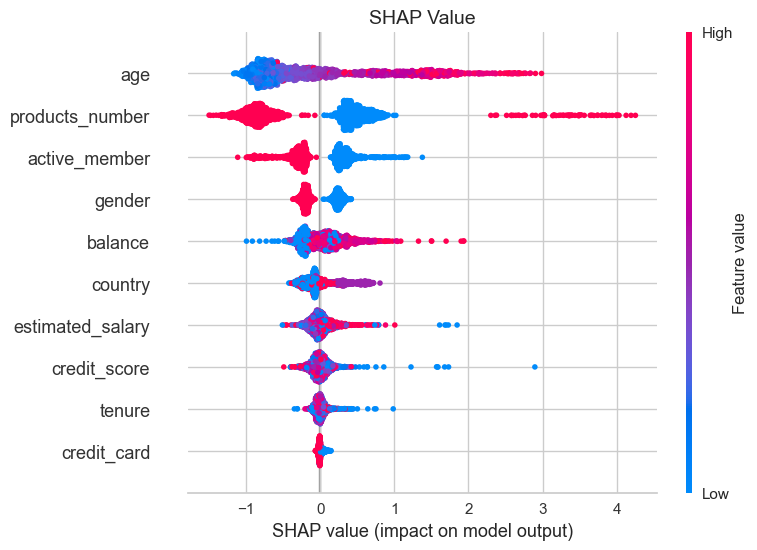

In [ ]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)

# SHAP - 여기서 그라디언트부스팅모델을 지정해서 사후분석 해보겠습니다.
explainer = shap.TreeExplainer(gbc)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정
if isinstance(shap_values, list): # 만약 결과가 리스트에 담겨있다면
    shap_values = shap_values[1] # 1번 부분만 가져와라
elif shap_values.ndim == 3: # 만약 결과가 3차원이라면 
    shap_values = shap_values[:, :, 1] # 3번째 부분만 가져와라
else: # 모두 그게 아니라면 
    shap_values = shap_values # 그대로 사용한다.

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot", # 점으로 표현
    show=False # 화면에 바로 띄우지말고 수정할 수 있도록 기다리게 한다.
)
plt.title("SHAP Value", fontsize=14) # 제목은 shap value 폰트 크기는 14
plt.show() # 그림을 보여달라


In [ ]:
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) F1_score, accuracy_score

est_model_list = [                                  # 전방 모델로써 리스트를 구성한다. (이름, 모델)
                ('cat', cat),
                ('lgbm', lgbm),
                ('gbc', gbc)
]

stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train) # 학습시킨다.

pred = stack.predict(X_valid) # 예측값 뽑는다.
print("Stacking F1:", f1_score(y_valid, pred)) # 예측값과 정답값으로 f1 스코어를 출력한다.

# 가장 핵심적인 현상은 고객의 충성도가 상품 개수에 비례하지 않는다는 점과 연령대가 높을수록 이탈 위험이 급격히 커진다는 것입니다.

# 이탈률에 가장 큰 영향을 미치는 요인은 나이입니다.
# 이는 은퇴 시점 전후의 고객들이 자산을 이동시키거나, 기존 은행의 서비스가 고령층의 니즈를 충분히 반영하지 못하고 있음을 알 수 있습니다. 
# 중장년층 고객을 위한 전용 자산 관리 서비스나 디지털 뱅킹 사용 편의성 강화를 하게 되면 이탈률이 줄어들것이라고 생각합니다.

# 다음으로는 상품개수와 충성도가 비례하지 않다는 점입니다.
# 단순히 상품 가입 수만 늘리는 양적 팽창 전략은 오히려 고객에게 관리의 피로도를 높이거나 이탈 시 더 큰 기회비용을 느끼게 할 수 있습니다.
# 고객이 여러 상품을 가입했을 때 실질적인 체감 혜택을 주는 패키지 리워드나 주거래 우대 제도의 실효성을 점검해야 합니다.

Stacking F1: 0.6021180030257186
